# TASK 2 — Unemployment Analysis with Python

## Objective: 
Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

## Step 1: Load, Inspect, and Prepare the Data

### 1.1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

### 1.2. Loading the Dataset

In [7]:
df = pd.read_csv(
    "/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv"
)


### 1.3. Inspecting the Shape

In [9]:
# Number of rows and number of colums
df.shape

(768, 7)

### 1.7. Check Missing Values

In [10]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Missing values are present in each column. To handle them, we first examine their distribution and determine whether the affected rows should be removed or the missing values should be imputed.

In [12]:
# First, inspect:
df[df.isnull().all(axis=1)].shape

(28, 7)

In [14]:
# Removing rows with missing values

df = df.dropna(
    how="all" # This operation removes only rows in which every value is missing, while preserving rows that may contain partial information.
)

# Verifying result
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [15]:
# Checking the new shape
df.shape

(740, 7)

### 1.8. Type Conversion

In [17]:
# Inspecting column names
df.columns.tolist()

['Region',
 ' Date',
 ' Frequency',
 ' Estimated Unemployment Rate (%)',
 ' Estimated Employed',
 ' Estimated Labour Participation Rate (%)',
 'Area']

In [21]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

# Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

#Verification
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

## Step 2: Exploratory Data Analysis

### 2.1. Region-wise Average Unemployment Rate

In [24]:
# Grouping all observations belonging to the same region and selecting the unemployment rate column.
# Calculating the average unemployment rate for each region.
# Sorting the regions from the highest average unemployment rate to the lowest.
regional_average = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

regional_average

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

### Observation — Region-wise Average Unemployment Rate

Average unemployment rates vary substantially across regions. Tripura recorded the highest average rate (28.35%), while Meghalaya recorded the lowest (4.80%), highlighting significant regional differences during the analyzed period.

### 2.2. Month-Wise Unemployment Trends

In [28]:
# Since we already converted the Date column to datetime, we can extract the month.
df["Month"] = df["Date"].dt.month

#calculating the average unemployment rate for each month:
monthly_average = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

#result

monthly_average

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

### Observation — Month-wise Unemployment Trends

Average unemployment was highest in April (23.64%), followed by May (16.65%), while the remaining months showed considerably lower rates, generally around 9–11%.

## Step 3: Time-Series Line Chart

### Objective:

Visualize the unemployment rate over time for at least three regions.

### 3.1. Inspecting available regions

In [29]:
df["Region"].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

In [31]:
#To see the regions and the number of observations for each:
df["Region"].value_counts()

Region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64

### 3.2. Selecting three major regions

In [32]:
selected_regions = [
    "Delhi",
    "Bihar",
    "Rajasthan"
]

### 3.3. Filtering the dataset

In [33]:
selected_df = df[
    df["Region"].isin(selected_regions)
]

### 3.4. Sorting chronologically

In [34]:
selected_df = selected_df.sort_values(
    by="Date"
)

### 3.5. Creating the line chart

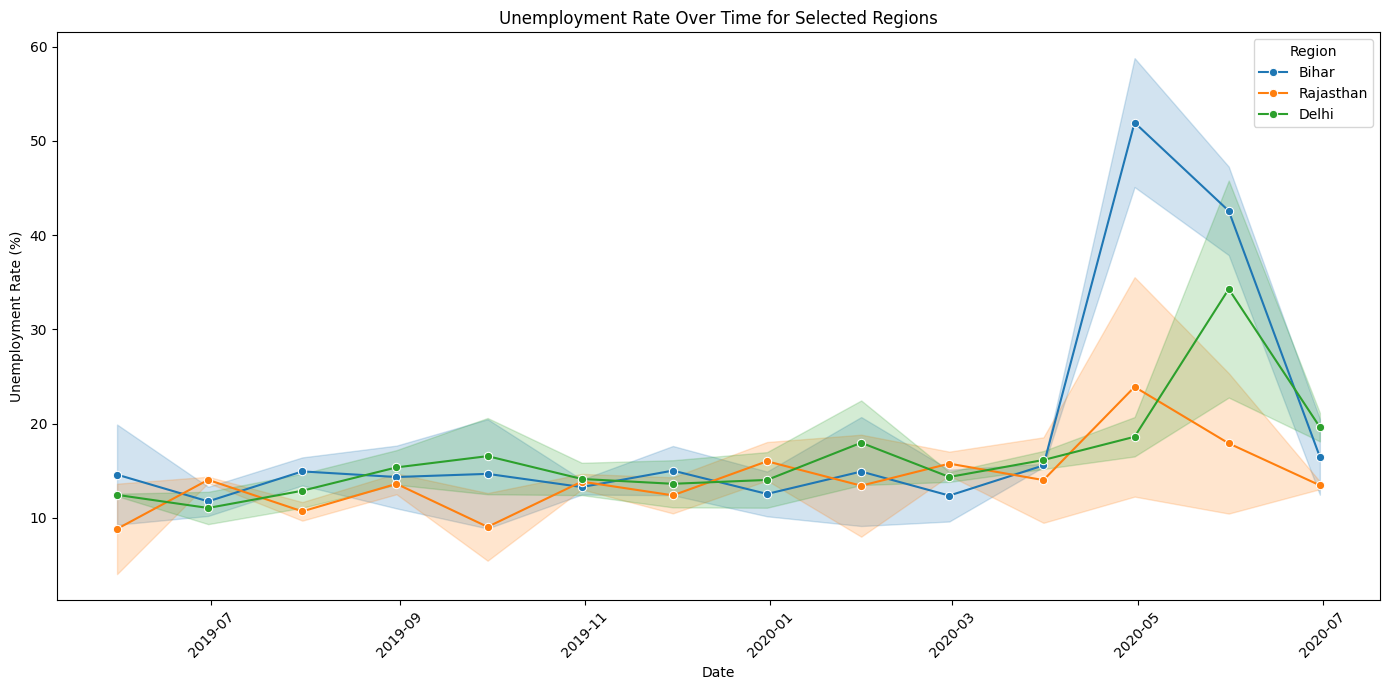

In [35]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=selected_df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title(
    "Unemployment Rate Over Time for Selected Regions"
)

plt.xlabel("Date")

plt.ylabel(
    "Unemployment Rate (%)"
)

plt.xticks(rotation=45)

plt.legend(
    title="Region"
)

plt.tight_layout()

plt.show()

### Observation

The time-series visualization shows how unemployment rates evolved over time across the three selected regions. The regions exhibit differences in both their average unemployment levels and the magnitude of their fluctuations. The chart also provides a visual basis for examining changes during the COVID-19 period, which will be analyzed quantitatively in a later section.

## Step 4: Bar Chart - Top 10 Regions with the Highest Average Unemployment Rate

Since the dataset column is named Region, we should use regions unless we verify that every value represents a state.

### 4.1. Calculating the average unemployment rate

In [37]:
top_10_regions = (
    df.groupby("Region")[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

### 4.2. Displaying the results

In [38]:
top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

### 4.3. Creating the bar chart

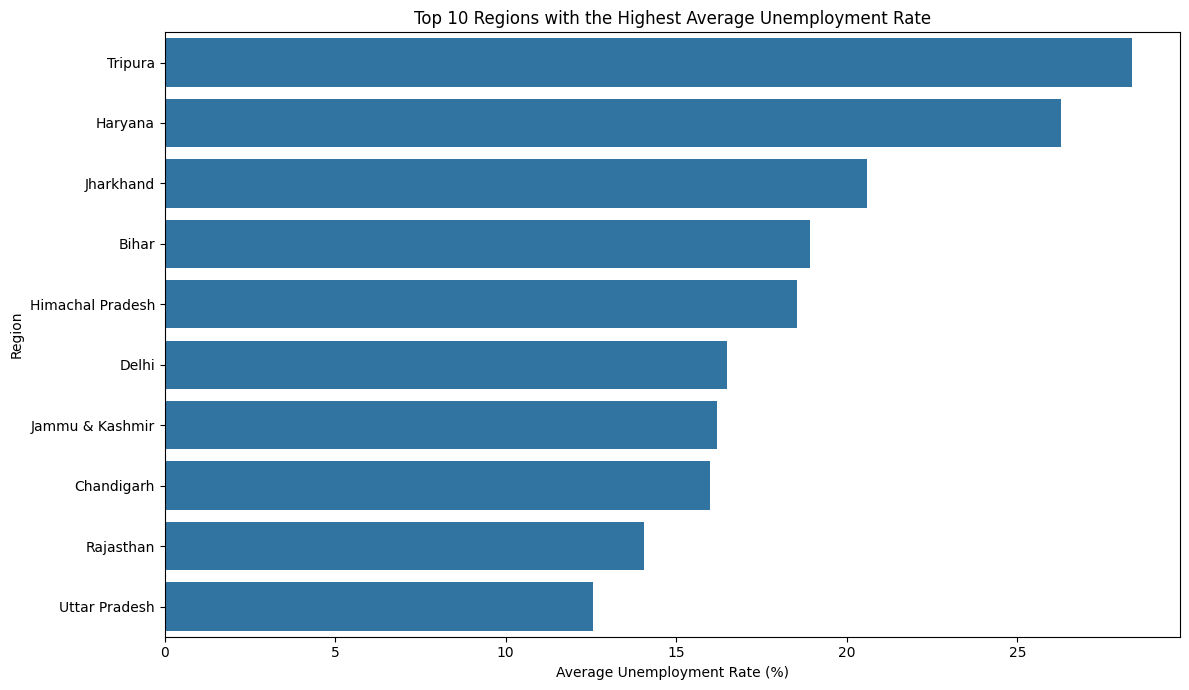

In [39]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title(
    "Top 10 Regions with the Highest Average Unemployment Rate"
)

plt.xlabel(
    "Average Unemployment Rate (%)"
)

plt.ylabel("Region")

plt.tight_layout()

plt.show()

### Observation

The bar chart shows that Tripura had the highest average unemployment rate (28.35%), followed by Haryana (26.28%) and Jharkhand (20.59%). The results highlight substantial differences in average unemployment levels across the ten highest-ranked regions.

## Step 5: Correlation Heatmap

We will analyze the correlation between:

+ Estimated Unemployment Rate (%)
+ Estimated Employed
+ Estimated Labour Participation Rate (%)

### 5.1. Selecting the relevant columns

In [40]:
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

### 5.2. Calculating the correlation matrix

In [41]:
correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


### 5.3. Creating the heatmap

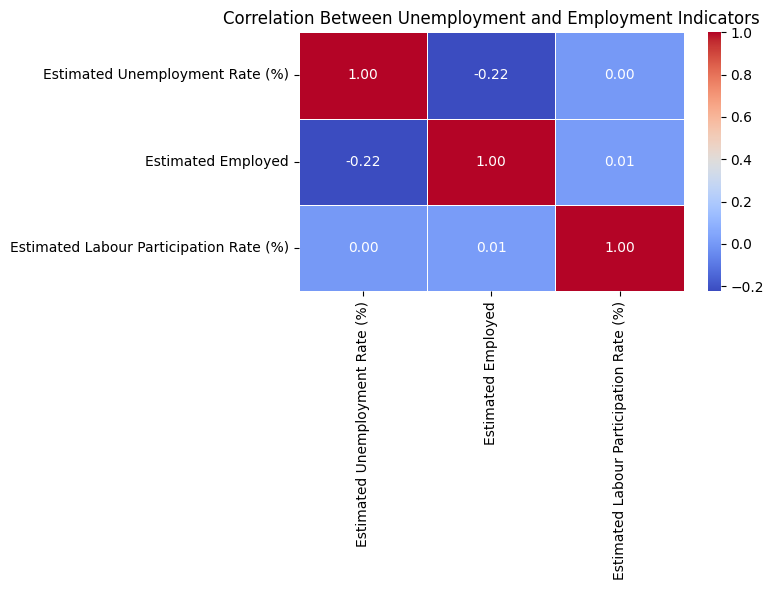

In [42]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Between Unemployment and Employment Indicators"
)

plt.tight_layout()

plt.show()

### Observation

The correlation analysis shows a weak negative relationship between the unemployment rate and estimated employment (r = −0.223). The correlations involving the labour participation rate are negligible (r ≈ 0), indicating no meaningful linear relationships among these variables in the dataset. Correlation does not imply causation.

## Step 6: Pre-COVID vs. Post-COVID Comparison

We will divide the dataset into two periods based on the date:

+ Pre-COVID: before March 2020
+ Post-COVID: March 2020 onward

### 6.1. Creating the periods

In [43]:
df["Period"] = np.where(
    df["Date"] < "2020-03-01",
    "Pre-COVID",
    "Post-COVID"
)

### 6.2. Calculating mean rates for each period

In [44]:
period_comparison = (
    df.groupby("Period")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
)

period_comparison

,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%)
Period,,
Post-COVID,17.774363,39.330049
Pre-COVID,9.509534,43.886119


### 6.3. Comparing the average unemployment rates

In [45]:
pre_covid_rate = period_comparison.loc[
    "Pre-COVID",
    "Estimated Unemployment Rate (%)"
]

post_covid_rate = period_comparison.loc[
    "Post-COVID",
    "Estimated Unemployment Rate (%)"
]

change = post_covid_rate - pre_covid_rate

print(f"Pre-COVID average: {pre_covid_rate:.2f}%")
print(f"Post-COVID average: {post_covid_rate:.2f}%")
print(f"Change: {change:.2f} percentage points")

Pre-COVID average: 9.51%
Post-COVID average: 17.77%
Change: 8.26 percentage points


### Observation

The average unemployment rate increased from 9.51% before COVID-19 to 17.77% afterward, representing an increase of 8.26 percentage points.